# Fake News Detection – Complete Notebook

Mirrors the production pipeline in `src/`:
- `src/components/data_ingestion.py`
- `src/components/feature_engineering.py`
- `src/components/model_training.py`
- `src/components/model_evaluation.py`
- `src/pipeline/prediction_pipeline.py`


## 1. Install Dependencies

In [1]:
%pip install -q wordcloud nltk scikit-learn pandas matplotlib seaborn joblib
import nltk
for _res in ('stopwords', 'wordnet', 'omw-1.4',
             'averaged_perceptron_tagger',
             'averaged_perceptron_tagger_eng'):   # FIX: both old and new name
    nltk.download(_res, quiet=True)


Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from wordcloud import WordCloud

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)


## 3. Load & Merge Data

Matches `DataIngestion` in `src/components/data_ingestion.py`.

In [3]:
# Relative paths — works on any machine
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))   # go up one level
FAKE_PATH = os.path.join(BASE_DIR, 'artifacts', 'Fake.csv')
TRUE_PATH = os.path.join(BASE_DIR, 'artifacts', 'True.csv')

fake_df = pd.read_csv(FAKE_PATH)
true_df = pd.read_csv(TRUE_PATH)
fake_df['label'] = 1
true_df['label'] = 0

# Keep only needed columns (avoids bloated artifacts)
fake_df = fake_df[['text', 'label']]
true_df = true_df[['text', 'label']]

df = pd.concat([fake_df, true_df], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df = df.drop_duplicates(subset=['text']).dropna(subset=['text', 'label']).reset_index(drop=True)
print(f'Total samples: {len(df)}')
df.head()


Total samples: 38646


,text,label
0,"21st Century Wire says Ben Stein, reputable pr...",1
1,WASHINGTON (Reuters) - U.S. President Donald T...,0
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,0
3,"On Monday, Donald Trump once again embarrassed...",1
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",0


## 4. Exploratory Data Analysis

In [4]:
print(df.shape)
df.info()


(38646, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38646 entries, 0 to 38645
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    38646 non-null  object
 1   label   38646 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 604.0+ KB


In [5]:
print('Missing values:')
print(df.isnull().sum())


Missing values:
text     0
label    0
dtype: int64


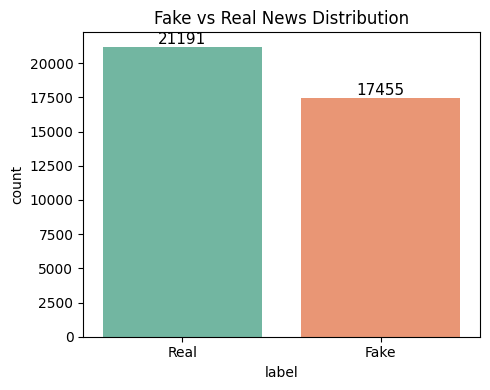

label
0    21191
1    17455
Name: count, dtype: int64


In [6]:
# Class balance — use order= to prevent accidental label swapping
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='label', order=[0, 1], palette='Set2', ax=ax)
ax.set_title('Fake vs Real News Distribution')
ax.set_xticklabels(['Real', 'Fake'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()
print(df.label.value_counts())


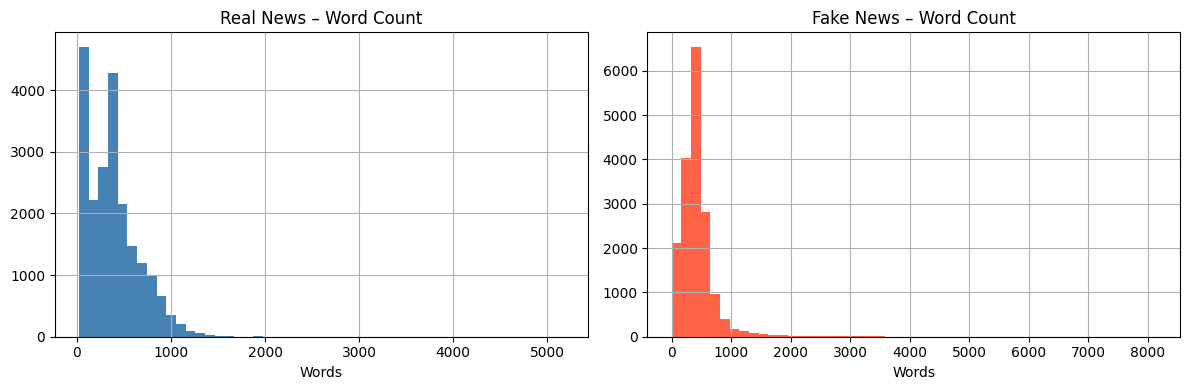

In [7]:
df['text_len'] = df['text'].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, name, ax in zip([0, 1], ['Real', 'Fake'], axes):
    df[df.label == label]['text_len'].hist(
        bins=50, ax=ax, color='steelblue' if label == 0 else 'tomato')
    ax.set_title(f'{name} News – Word Count')
    ax.set_xlabel('Words')
plt.tight_layout(); plt.show()


## 5. Text Preprocessing

Matches `clean_text()` in `src/components/feature_engineering.py`.

- Contraction expansion
- **POS-aware lemmatisation** (verbs/adjectives/adverbs handled correctly)
- URL, bracket, punctuation removal


In [8]:
CONTRACTIONS = {
    "don't": 'do not', "doesn't": 'does not', "can't": 'cannot',
    "won't": 'will not', "isn't": 'is not', "aren't": 'are not',
    "wasn't": 'was not', "weren't": 'were not', "hasn't": 'has not',
    "haven't": 'have not', "didn't": 'did not', "wouldn't": 'would not',
    "couldn't": 'could not', "shouldn't": 'should not', "i'm": 'i am',
    "i've": 'i have', "i'll": 'i will', "i'd": 'i would',
    "they're": 'they are', "they've": 'they have', "it's": 'it is',
    "that's": 'that is', "there's": 'there is',
}

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# FIX: newer NLTK (3.9+) renamed the tagger — download both names to be safe
for _tagger in ('averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng'):
    nltk.download(_tagger, quiet=True)

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(re.escape(k), v, text, flags=re.IGNORECASE)
    return text

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]
    try:
        tagged = pos_tag(tokens)
        tokens = [lemmatizer.lemmatize(t, get_wordnet_pos(p)) for t, p in tagged]
    except Exception:
        # Fallback: lemmatize without POS if tagger unavailable
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
print('Sample cleaned:')
print(df['clean_text'].iloc[0][:300])


Sample cleaned:
century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day make provocative statement judge jeanine pirro show recently discuss halt impose president trump executive order travel stein refer judgement circuit court washington state


## 6. Word Clouds

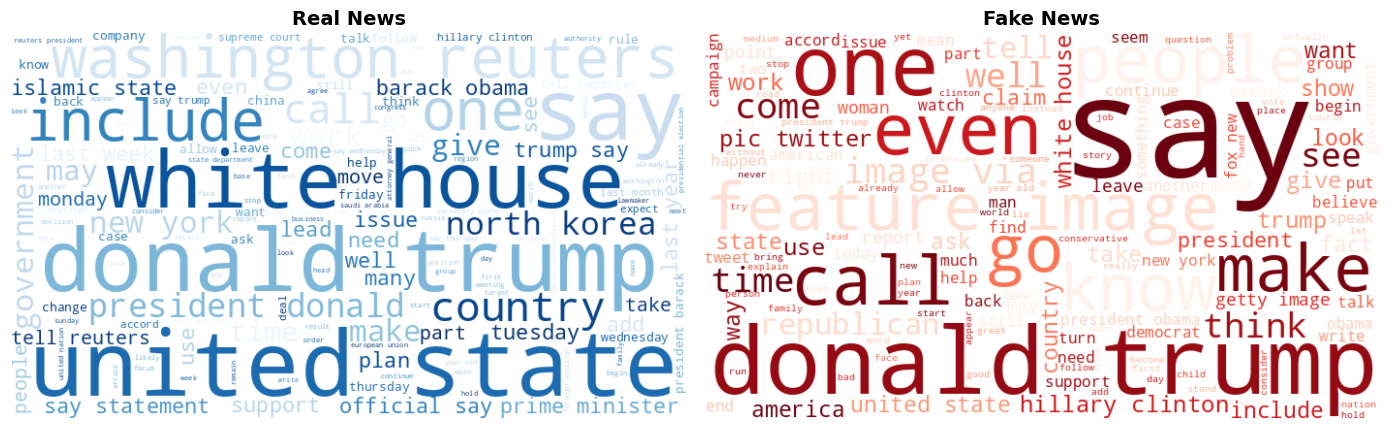

In [9]:
real_words = ' '.join(df[df.label == 0]['clean_text'])
fake_words = ' '.join(df[df.label == 1]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, words, title, cmap in zip(
        axes, [real_words, fake_words], ['Real News', 'Fake News'], ['Blues', 'Reds']):
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=cmap, max_words=150).generate(words)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.show()


## 7. Train / Validation / Test Split (70 / 10 / 20)

Stratified splits — matches `ModelTrainer`.

In [10]:
X = df['clean_text']
y = df['label']

X_trval, X_test, y_trval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trval, y_trval, test_size=0.125, random_state=SEED, stratify=y_trval)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')


Train : 27051
Val   : 3865
Test  : 7730


## 8. TF-IDF Vectorisation

Bigrams, min_df=3, sublinear TF. Fitted on train only — no leakage.

In [11]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.70,
    min_df=3,
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_features=60_000,
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

print(f'Vocabulary : {len(vectorizer.vocabulary_):,}')
print(f'Train shape: {X_train_vec.shape}')


Vocabulary : 60,000
Train shape: (27051, 60000)


## 9. Model Training & Evaluation

PAC is wrapped in `CalibratedClassifierCV` — matches `ModelTrainer._candidate_models()`.
All three models now expose `predict_proba()` with meaningful probabilities.


In [12]:
pac_base = PassiveAggressiveClassifier(C=0.1, max_iter=1000, random_state=SEED)

MODELS = {
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Passive Aggressive':  CalibratedClassifierCV(pac_base, cv=3),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000,
                                               random_state=SEED, solver='lbfgs'),
}

trained_models = {}
results = []

for name, clf in MODELS.items():
    clf.fit(X_train_vec, y_train)
    trained_models[name] = clf

    yv  = clf.predict(X_val_vec)
    yt  = clf.predict(X_test_vec)
    y_score = clf.predict_proba(X_test_vec)[:, 1]

    results.append({
        'Model':     name,
        'Val Acc':   accuracy_score(y_val, yv),
        'Val F1':    f1_score(y_val, yv),
        'Test Acc':  accuracy_score(y_test, yt),
        'Precision': precision_score(y_test, yt),
        'Recall':    recall_score(y_test, yt),
        'F1':        f1_score(y_test, yt),
        'ROC-AUC':   roc_auc_score(y_test, y_score),
        '_yt':       yt,
        '_score':    y_score,
    })
    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(classification_report(y_test, yt, target_names=['Real', 'Fake']))


  Naive Bayes
              precision    recall  f1-score   support

        Real       0.96      0.96      0.96      4239
        Fake       0.95      0.95      0.95      3491

    accuracy                           0.96      7730
   macro avg       0.95      0.96      0.96      7730
weighted avg       0.96      0.96      0.96      7730

  Passive Aggressive
              precision    recall  f1-score   support

        Real       0.99      1.00      1.00      4239
        Fake       1.00      0.99      0.99      3491

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730

  Logistic Regression
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4239
        Fake       0.99      0.98      0.99      3491

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg     

## 10. Confusion Matrices

Reuses stored `_yt` predictions — no redundant `.predict()` calls.

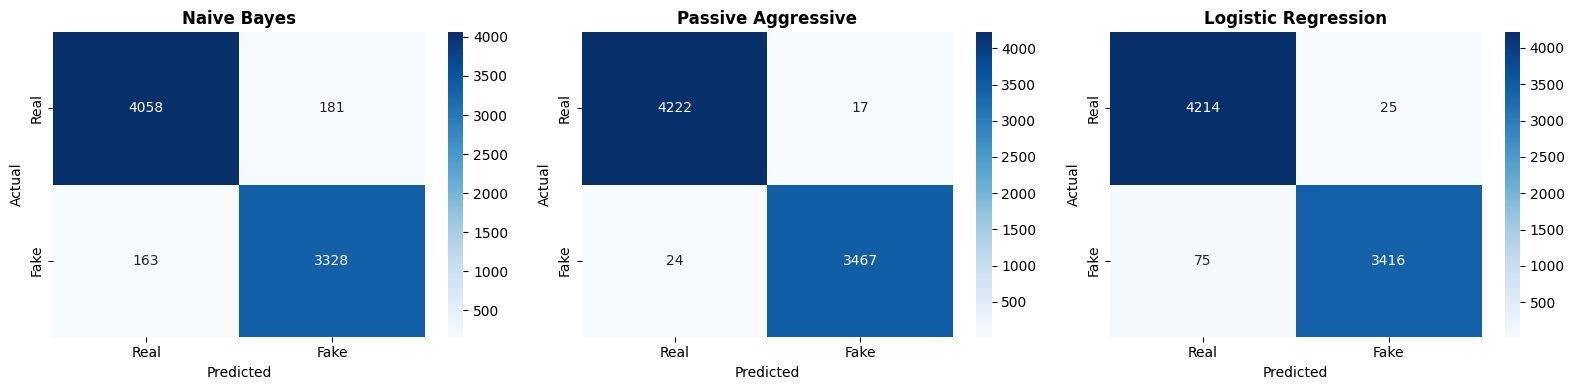

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, row in zip(axes, results):
    cm = confusion_matrix(y_test, row['_yt'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    ax.set_title(row['Model'], fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


## 11. ROC-AUC Curves

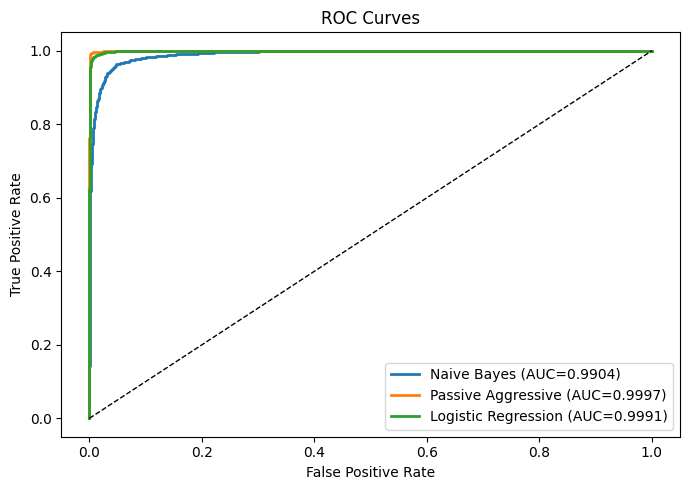

In [14]:
plt.figure(figsize=(7, 5))
for row in results:
    fpr, tpr, _ = roc_curve(y_test, row['_score'])
    plt.plot(fpr, tpr, lw=2, label=f"{row['Model']} (AUC={row['ROC-AUC']:.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


## 12. Model Comparison

              Model  Val Acc   Val F1  Test Acc  Precision   Recall       F1  ROC-AUC
 Passive Aggressive 0.994049 0.993393  0.994696   0.995121 0.993125 0.994122 0.999686
Logistic Regression 0.986546 0.984988  0.987063   0.992735 0.978516 0.985574 0.999063
        Naive Bayes 0.953687 0.948872  0.955498   0.948418 0.953309 0.950857 0.990388


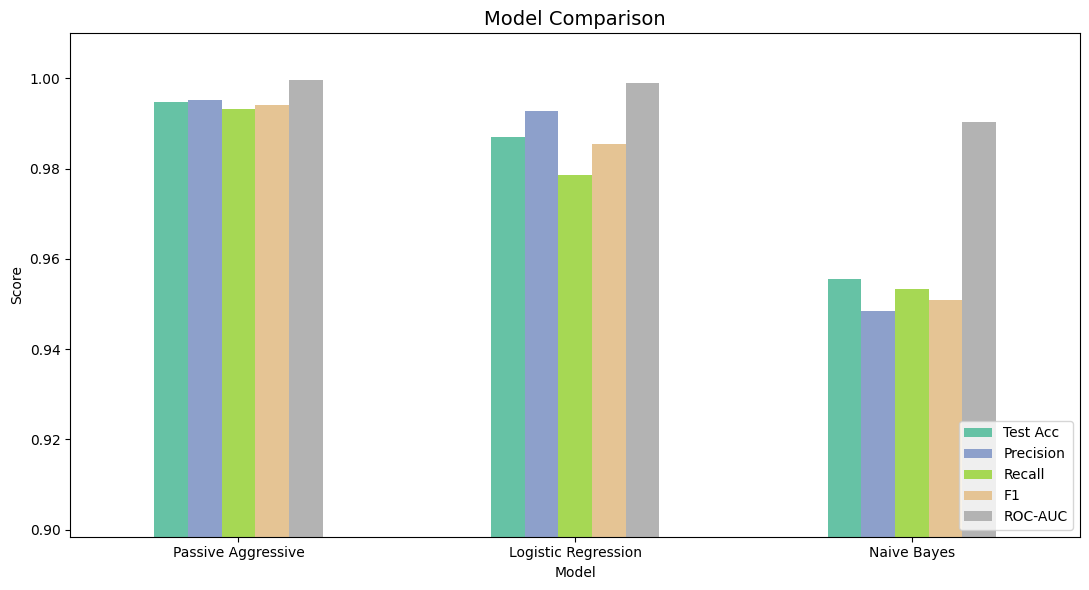

In [15]:
METRIC_COLS = ['Test Acc', 'Precision', 'Recall', 'F1', 'ROC-AUC']

results_df = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
    .sort_values('Val F1', ascending=False)
    .reset_index(drop=True)
)
print(results_df.to_string(index=False))

y_min = results_df[METRIC_COLS].min().min()
results_df.set_index('Model')[METRIC_COLS].plot(
    kind='bar', figsize=(11, 6),
    ylim=(max(0, y_min - 0.05), 1.01),
    colormap='Set2')
plt.title('Model Comparison', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


## 13. Top TF-IDF Features

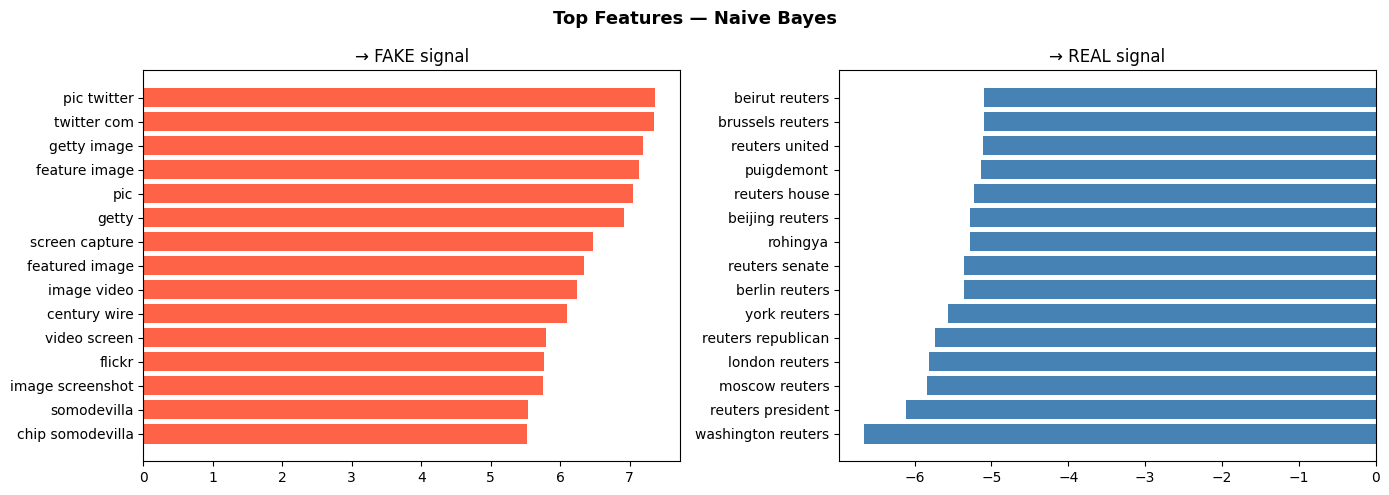

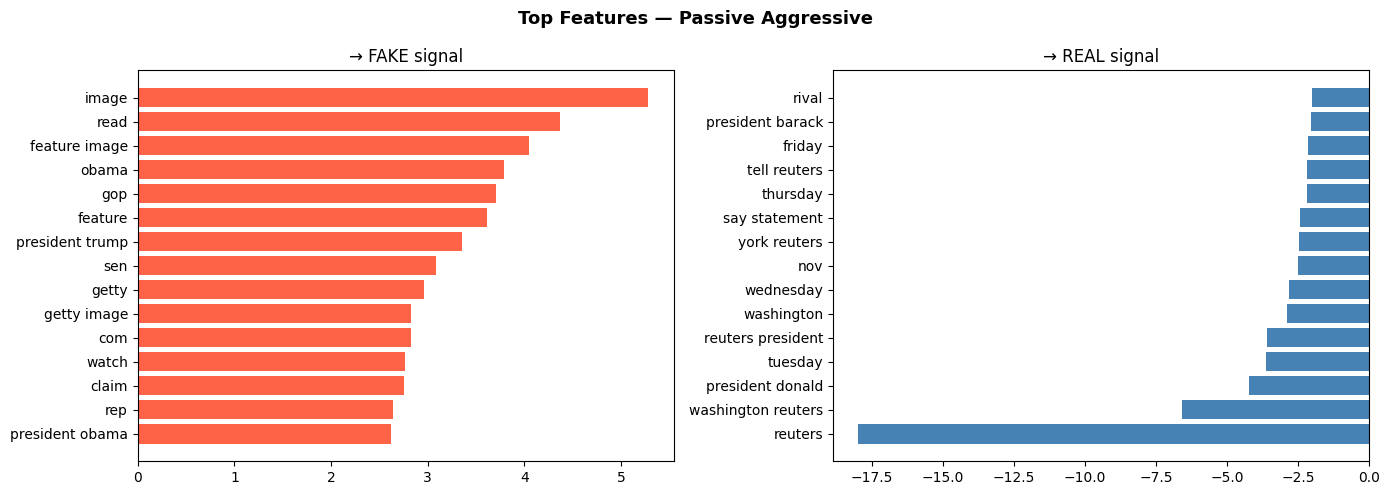

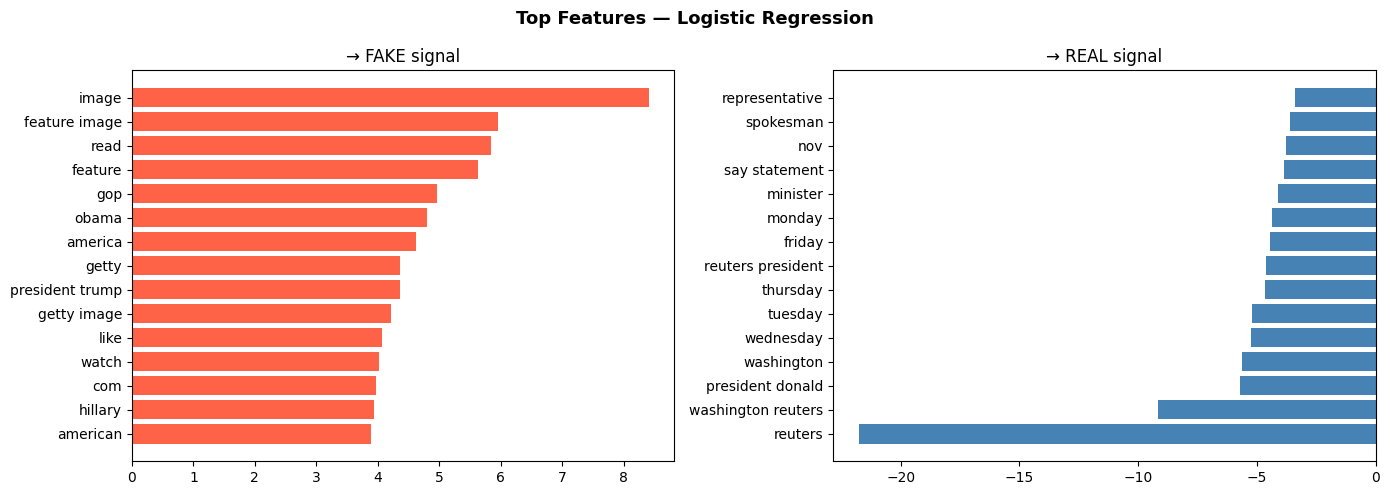

In [20]:
def plot_top_features(model_name, clf, vectorizer, n=15):
    feature_names = vectorizer.get_feature_names_out()

    if hasattr(clf, 'feature_log_prob_'):
        # Naive Bayes — use log probability difference (fake - real)
        scores = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]

    elif hasattr(clf, 'coef_'):
        # Logistic Regression — coef_ directly
        scores = clf.coef_[0]

    elif hasattr(clf, 'calibrated_classifiers_'):
        # CalibratedClassifierCV wrapping PAC — dig into base estimator
        base = clf.calibrated_classifiers_[0].estimator
        if hasattr(base, 'coef_'):
            scores = base.coef_[0]
        else:
            print(f"{model_name}: cannot extract feature importance")
            return
    else:
        print(f"{model_name}: no feature importance available")
        return

    # Top fake-signal words (highest scores)
    top_fake_idx = scores.argsort()[::-1][:n]
    # Top real-signal words (lowest scores)
    top_real_idx = scores.argsort()[:n]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Top Features — {model_name}', fontsize=13, fontweight='bold')

    for ax, idx, title, color in zip(
            axes,
            [top_fake_idx, top_real_idx[::-1]],
            ['→ FAKE signal', '→ REAL signal'],
            ['tomato', 'steelblue']):
        ax.barh(feature_names[idx], scores[idx], color=color)
        ax.set_title(title)
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


for name, clf in trained_models.items():
    plot_top_features(name, clf, vectorizer)

## 14. Save Best Model & Vectorizer

Matches `ModelTrainer.initiate_model_training()` save logic.

In [21]:
os.makedirs('artifacts', exist_ok=True)

best_name = results_df.iloc[0]['Model']
best_clf  = trained_models[best_name]
print(f'Best model (by Val F1): {best_name}')

joblib.dump(best_clf,   'artifacts/model.joblib')
joblib.dump(vectorizer, 'artifacts/vectorizer.joblib')

metrics_out = {
    'best_model': best_name,
    'selection_metric': 'validation_f1',
    'models': [
        {k: v for k, v in r.items() if not k.startswith('_')}
        for r in results
    ],
}
with open('artifacts/metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print('Saved → artifacts/model.joblib')
print('Saved → artifacts/vectorizer.joblib')
print('Saved → artifacts/metrics.json')


Best model (by Val F1): Passive Aggressive
Saved → artifacts/model.joblib
Saved → artifacts/vectorizer.joblib
Saved → artifacts/metrics.json


## 15. Inference

Mirrors `PredictionPipeline.predict()`. All models have `predict_proba` — confidence is real.


In [22]:
model_loaded = joblib.load('artifacts/model.joblib')
vec_loaded   = joblib.load('artifacts/vectorizer.joblib')

def predict_news(text):
    if not text or not text.strip():
        raise ValueError('Input text cannot be empty')
    cleaned  = clean_text(text)
    vec      = vec_loaded.transform([cleaned])
    pred     = model_loaded.predict(vec)[0]
    conf     = model_loaded.predict_proba(vec).max() * 100
    label    = 'FAKE' if pred == 1 else 'REAL'
    return f'[{label}] ({conf:.1f}% confidence)'

tests = [
    'The government has announced a new policy to support farmers.',
    'BREAKING: Scientists discover chocolate cures all diseases overnight!',
    'The Federal Reserve raised interest rates by 25 basis points.',
    'Aliens landed in New York and had dinner with the president.',
]
print(f'Model: {best_name}\n')
for t in tests:
    print(f'{predict_news(t):<42} {t[:72]}')


Model: Passive Aggressive

[FAKE] (96.5% confidence)                  The government has announced a new policy to support farmers.
[FAKE] (96.7% confidence)                  BREAKING: Scientists discover chocolate cures all diseases overnight!
[FAKE] (78.7% confidence)                  The Federal Reserve raised interest rates by 25 basis points.
[FAKE] (91.5% confidence)                  Aliens landed in New York and had dinner with the president.
